# Checkpoint Reconstruction Analysis

TODOs answered here:

1. What is the relationship between sequence length and reconstruction loss?
2. How does the reconstruction loss evolve over epochs for different sequence lengths?
3. Are there some amino acids that are more likely to be reconstructed incorrectly?

`outputs/output_results.csv` contains per-example `token_accuracy`, but not per-example cross-entropy loss or epoch. This notebook uses `1 - token_accuracy` as a per-example reconstruction-error proxy for questions 1 and 3. Question 2 can only be answered by sequence-length bin if per-epoch reconstruction outputs are saved; the notebook plots available global history now and includes a guarded cell for future per-epoch length-binned files.

In [1]:
from pathlib import Path
import json
import os

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "outputs" / "output_results.csv").exists():
    for parent in Path.cwd().parents:
        if (parent / "outputs" / "output_results.csv").exists():
            PROJECT_ROOT = parent
            break

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib_cache"))
(PROJECT_ROOT / ".matplotlib_cache").mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

RESULTS_PATH = PROJECT_ROOT / "outputs" / "output_results.csv"
HISTORY_DIR = PROJECT_ROOT / "history"
print(f"Project root: {PROJECT_ROOT}")
print(f"Results CSV: {RESULTS_PATH}")

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/josh/GWU/protein-sequence-augmentation
Results CSV: /Users/josh/GWU/protein-sequence-augmentation/outputs/output_results.csv


In [2]:
results = pd.read_csv(RESULTS_PATH)
numeric_cols = ["target_length", "predicted_length", "token_accuracy"]
results[numeric_cols] = results[numeric_cols].apply(pd.to_numeric, errors="coerce")
results = results.dropna(subset=numeric_cols).copy()

# output_results.csv does not include cross-entropy loss, so this is a token-error proxy.
results["reconstruction_error"] = 1.0 - results["token_accuracy"]
results["length_delta"] = results["predicted_length"] - results["target_length"]
results["abs_length_delta"] = results["length_delta"].abs()
results["length_bin"] = pd.qcut(
    results["target_length"],
    q=4,
    labels=["short", "medium-short", "medium-long", "long"],
    duplicates="drop",
)

summary = results[["target_length", "predicted_length", "token_accuracy", "reconstruction_error", "length_delta"]].describe()
display(summary)
display(results.groupby("length_bin", observed=True)[["target_length", "token_accuracy", "reconstruction_error", "abs_length_delta"]].agg(["count", "mean", "median", "std"]))

,target_length,predicted_length,token_accuracy,reconstruction_error,length_delta
count,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000
mean,296.329165,306.563282,0.221885,0.778115,10.234117
std,185.184135,157.307713,0.072623,0.072623,73.411065
min,34.000000,36.000000,0.049958,0.457143,-552.000000
25%,159.000000,172.000000,0.172061,0.737331,0.000000
50%,260.000000,287.000000,0.209974,0.790026,8.000000
75%,379.000000,410.500000,0.262669,0.827940,19.000000
max,1200.000000,939.000000,0.542857,0.950042,393.000000


target_length                                token_accuracy  \
                     count        mean median         std          count   
length_bin                                                                 
short                  502  116.683267  121.0   28.437509            502   
medium-short           501  210.808383  211.0   29.545748            501   
medium-long            500  315.848000  312.0   34.111818            500   
long                   496  544.854839  482.0  182.044747            496   

                                           reconstruction_error            \
                  mean    median       std                count      mean   
length_bin                                                                  
short         0.311527  0.305410  0.060736                  502  0.688473   
medium-short  0.233895  0.232323  0.033640                  501  0.766105   
medium-long   0.192562  0.191366  0.027538                  500  0.807438   
long          0.148587  0.150249  0.033161                  496  0.851413   

                                 abs_length_delta                               
                median       std            count       mean median        std  
length_bin                                                                      
short         0.694590  0.060736              502  11.862550    6.0  31.568432  
medium-short  0.767677  0.033640              501  30.469062   15.0  51.934165  
medium-long   0.808634  0.027538              500  34.098000   15.0  56.012778  
long          0.849751  0.033161              496  58.780242   18.5  97.780387

## 1. Sequence Length vs Reconstruction Error

The scatter/LOWESS plot shows whether longer sequences tend to have higher token reconstruction error. The boxplot compares the same error proxy across target-length quartiles.

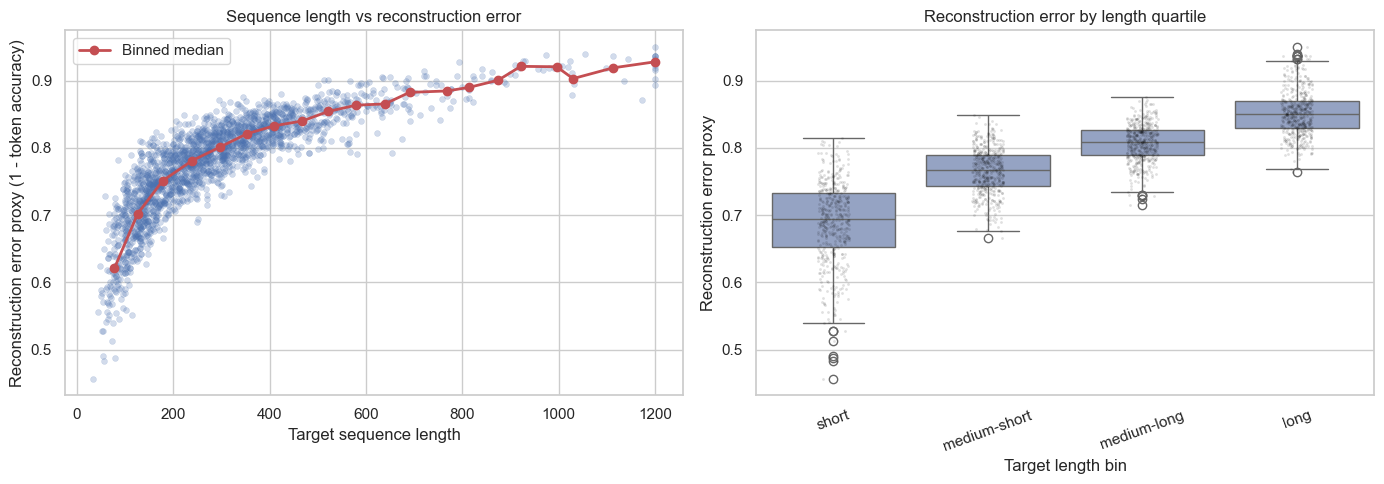

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=results,
    x="target_length",
    y="reconstruction_error",
    alpha=0.25,
    s=18,
    edgecolor=None,
    ax=axes[0],
)

trend = (
    results.assign(length_window=pd.cut(results["target_length"], bins=20))
    .groupby("length_window", observed=True)
    .agg(
        target_length=("target_length", "median"),
        reconstruction_error=("reconstruction_error", "median"),
    )
    .dropna()
)

axes[0].plot(
    trend["target_length"],
    trend["reconstruction_error"],
    color="#c44e52",
    linewidth=2,
    marker="o",
    label="Binned median",
)
axes[0].legend()
axes[0].set_title("Sequence length vs reconstruction error")
axes[0].set_xlabel("Target sequence length")
axes[0].set_ylabel("Reconstruction error proxy (1 - token accuracy)")

sns.boxplot(data=results, x="length_bin", y="reconstruction_error", ax=axes[1], color="#8da0cb")
sns.stripplot(data=results, x="length_bin", y="reconstruction_error", ax=axes[1], color="black", alpha=0.12, size=2)
axes[1].set_title("Reconstruction error by length quartile")
axes[1].set_xlabel("Target length bin")
axes[1].set_ylabel("Reconstruction error proxy")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [5]:
spearman_r, spearman_p = stats.spearmanr(results["target_length"], results["reconstruction_error"])
pearson_r, pearson_p = stats.pearsonr(results["target_length"], results["reconstruction_error"])

groups = [g["reconstruction_error"].to_numpy() for _, g in results.groupby("length_bin", observed=True)]
kruskal_h, kruskal_p = stats.kruskal(*groups)

q1_stats = pd.DataFrame(
    [
        {"test": "Spearman length vs error", "statistic": spearman_r, "p_value": spearman_p},
        {"test": "Pearson length vs error", "statistic": pearson_r, "p_value": pearson_p},
        {"test": "Kruskal-Wallis error across length bins", "statistic": kruskal_h, "p_value": kruskal_p},
    ]
)
display(q1_stats)

alpha = 0.05
print(
    f"Spearman rho={spearman_r:.3f}, p={spearman_p:.3g}. "
    f"Length-bin Kruskal-Wallis p={kruskal_p:.3g}. "
    f"At alpha={alpha}, the length/error association is "
    f"{'statistically detectable' if spearman_p < alpha else 'not statistically detectable'} in this output file."
)

,test,statistic,p_value
0,Spearman length vs error,0.893869,0.0
1,Pearson length vs error,0.786667,0.0
2,Kruskal-Wallis error across length bins,1484.648906,0.0


Spearman rho=0.894, p=0. Length-bin Kruskal-Wallis p=0. At alpha=0.05, the length/error association is statistically detectable in this output file.


## 2. Reconstruction Loss Over Epochs by Sequence Length

`output_results.csv` has final checkpoint outputs only, so it cannot show epoch-by-epoch behavior. The first plot below uses the available global training-history JSON files. The second cell will automatically plot length-binned epoch metrics if files matching `outputs/*epoch*length*.csv` or `outputs/*length*epoch*.csv` exist with columns like `epoch`, `length_bin`, and `reconstruction_loss` or `reconstruction_error`.

In [ ]:
# history_rows = []
# for path in sorted(HISTORY_DIR.glob("**/*.json")):
#     try:
#         history = json.loads(path.read_text())
#     except json.JSONDecodeError:
#         continue
#     for record in history.get("epochs", []):
#         history_rows.append(
#             {
#                 "history": str(path.relative_to(PROJECT_ROOT)),
#                 "epoch": record.get("epoch"),
#                 "train_loss": record.get("train_loss"),
#                 "val_loss": record.get("val_loss"),
#                 "train_accuracy": record.get("train_accuracy"),
#                 "val_accuracy": record.get("val_accuracy"),
#                 "curriculum_fraction": record.get("curriculum_fraction"),
#                 "curriculum_examples": record.get("curriculum_examples"),
#             }
#         )

# history_df = pd.DataFrame(history_rows)
# history_df = history_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["epoch", "train_loss", "val_loss"])

# focus_histories = [
#     "history/v1/ae_v1_history.json",
#     "history/v2/solubility_ae_history.json",
#     "history/v3/solubility_ae_history.json",
#     "history/solubility_ae_history.json",
# ]
# plot_history = history_df[history_df["history"].isin(focus_histories)].copy()
# display(plot_history.groupby("history")[["epoch", "train_loss", "val_loss", "val_accuracy"]].tail(1).sort_values("history"))

# history_long = plot_history.melt(
#     id_vars=["history", "epoch"],
#     value_vars=["train_loss", "val_loss"],
#     var_name="split",
#     value_name="loss",
# )

# plt.figure(figsize=(12, 6))
# sns.lineplot(data=history_long, x="epoch", y="loss", hue="history", style="split", marker="o")
# plt.title("Available global reconstruction loss over epochs")
# plt.xlabel("Epoch")
# plt.ylabel("Cross-entropy reconstruction loss")
# plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
# plt.tight_layout()
# plt.show()

# trend_rows = []
# for history_name, g in plot_history.groupby("history"):
#     if len(g) >= 3:
#         rho, p = stats.spearmanr(g["epoch"], g["val_loss"], nan_policy="omit")
#         trend_rows.append({"history": history_name, "n_epochs": len(g), "spearman_epoch_vs_val_loss": rho, "p_value": p})
# display(pd.DataFrame(trend_rows))

KeyError: 'history'

In [ ]:
# candidate_files = sorted(set((PROJECT_ROOT / "outputs").glob("*epoch*length*.csv")) | set((PROJECT_ROOT / "outputs").glob("*length*epoch*.csv")))

# if not candidate_files:
#     print("No per-epoch length-binned reconstruction files found in outputs/.")
#     print("To answer this directly, save checkpoint evaluation rows with at least: epoch, target_length, token_accuracy or reconstruction_loss.")
# else:
#     per_epoch = pd.concat([pd.read_csv(path).assign(source=path.name) for path in candidate_files], ignore_index=True)
#     if "reconstruction_loss" in per_epoch.columns:
#         metric_col = "reconstruction_loss"
#     elif "reconstruction_error" in per_epoch.columns:
#         metric_col = "reconstruction_error"
#     elif "token_accuracy" in per_epoch.columns:
#         per_epoch["reconstruction_error"] = 1.0 - pd.to_numeric(per_epoch["token_accuracy"], errors="coerce")
#         metric_col = "reconstruction_error"
#     else:
#         raise ValueError("Per-epoch files must include reconstruction_loss, reconstruction_error, or token_accuracy.")

#     if "length_bin" not in per_epoch.columns:
#         per_epoch["length_bin"] = pd.qcut(pd.to_numeric(per_epoch["target_length"], errors="coerce"), q=4, labels=["short", "medium-short", "medium-long", "long"], duplicates="drop")

#     epoch_length_summary = per_epoch.groupby(["epoch", "length_bin"], observed=True)[metric_col].mean().reset_index()
#     plt.figure(figsize=(10, 5))
#     sns.lineplot(data=epoch_length_summary, x="epoch", y=metric_col, hue="length_bin", marker="o")
#     plt.title("Length-binned reconstruction metric over epochs")
#     plt.xlabel("Epoch")
#     plt.ylabel(metric_col.replace("_", " "))
#     plt.tight_layout()
#     plt.show()

#     trend_tests = []
#     for length_bin, g in epoch_length_summary.groupby("length_bin", observed=True):
#         if len(g) >= 3:
#             rho, p = stats.spearmanr(g["epoch"], g[metric_col], nan_policy="omit")
#             trend_tests.append({"length_bin": length_bin, "spearman_epoch_vs_metric": rho, "p_value": p})
#     display(pd.DataFrame(trend_tests))

No per-epoch length-binned reconstruction files found in outputs/.
To answer this directly, save checkpoint evaluation rows with at least: epoch, target_length, token_accuracy or reconstruction_loss.


## 3. Amino-Acid Specific Reconstruction Errors

This section compares each target amino acid to the predicted amino acid at the same decoder position. If the prediction ended early, remaining target positions are counted as incorrect. This matches the token-level reconstruction framing used by `test_autoencoder.py`.

In [8]:
aa_rows = []
confusion_rows = []

for row in results.itertuples(index=False):
    target = str(row.target_sequence)
    predicted = str(row.predicted_sequence)
    for pos, target_aa in enumerate(target):
        predicted_aa = predicted[pos] if pos < len(predicted) else "<END>"
        correct = target_aa == predicted_aa
        aa_rows.append({"target_aa": target_aa, "correct": correct, "position": pos, "example_index": row.example_index})
        confusion_rows.append({"target_aa": target_aa, "predicted_aa": predicted_aa})

aa_df = pd.DataFrame(aa_rows)
aa_summary = (
    aa_df.groupby("target_aa")
    .agg(n_tokens=("correct", "size"), n_incorrect=("correct", lambda s: (~s).sum()), accuracy=("correct", "mean"))
    .assign(error_rate=lambda d: 1.0 - d["accuracy"])
    .sort_values("error_rate", ascending=False)
)
display(aa_summary)

,n_tokens,n_incorrect,accuracy,error_rate
target_aa,,,,
W,7214,7176,0.005268,0.994732
Y,19389,18627,0.039301,0.960699
T,31469,29120,0.074645,0.925355
C,7407,6806,0.081139,0.918861
Q,23337,21382,0.083773,0.916227
V,37944,34361,0.094429,0.905571
F,22667,19991,0.118057,0.881943
P,27438,23747,0.134521,0.865479
K,34686,29912,0.137635,0.862365


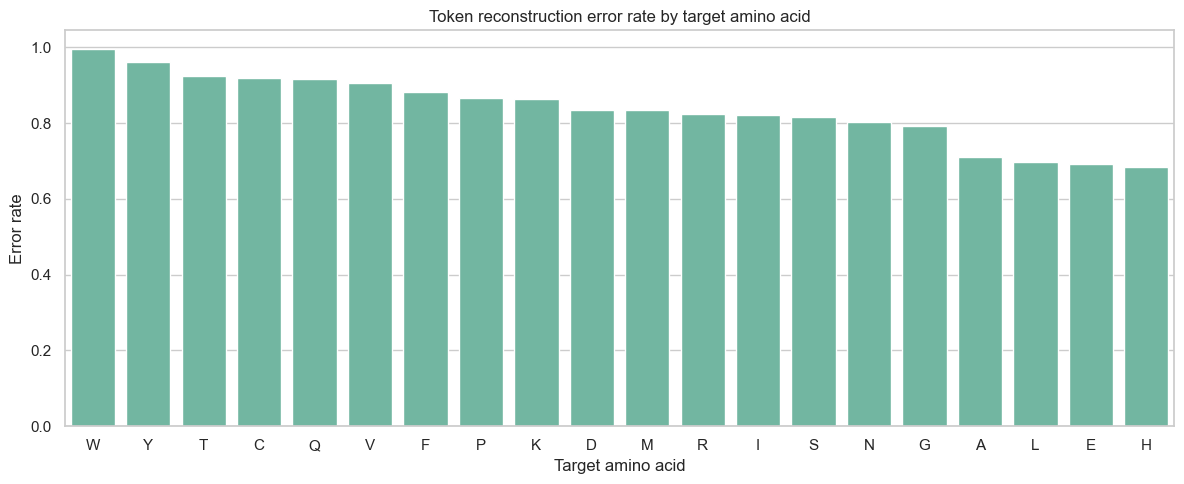

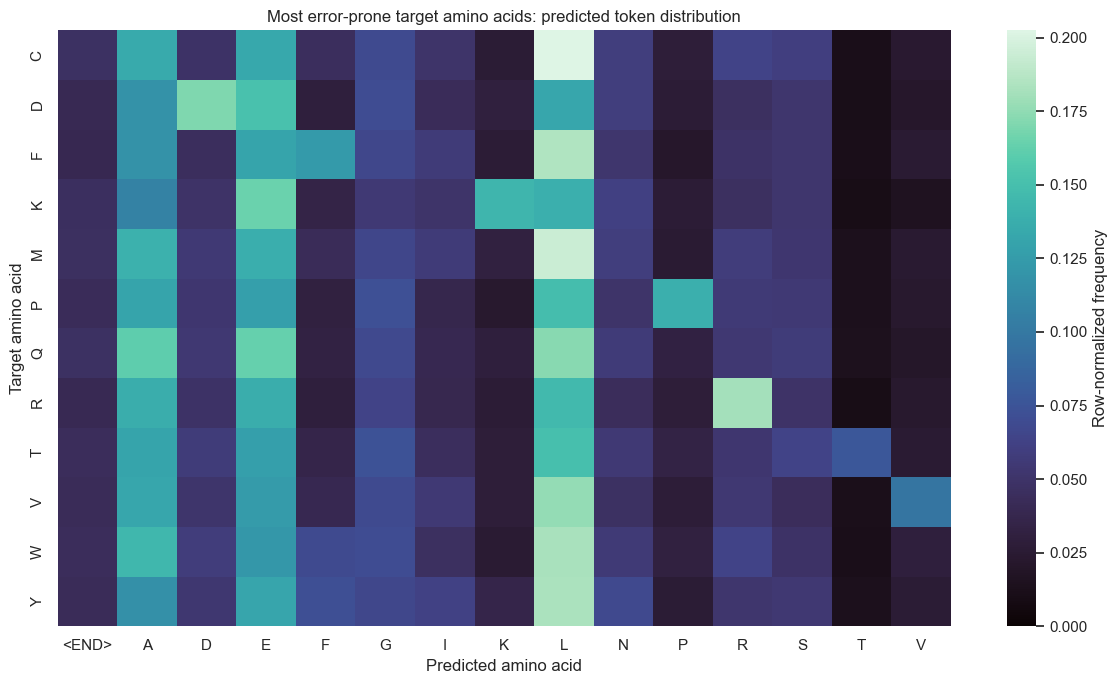

In [9]:
plt.figure(figsize=(12, 5))
plot_df = aa_summary.reset_index().sort_values("error_rate", ascending=False)
sns.barplot(data=plot_df, x="target_aa", y="error_rate", color="#66c2a5")
plt.title("Token reconstruction error rate by target amino acid")
plt.xlabel("Target amino acid")
plt.ylabel("Error rate")
plt.tight_layout()
plt.show()

top_targets = aa_summary.head(12).index.tolist()
confusion_df = pd.DataFrame(confusion_rows)
confusion_top = confusion_df[confusion_df["target_aa"].isin(top_targets)].copy()
top_predictions = confusion_top["predicted_aa"].value_counts().head(15).index.tolist()
confusion_top = confusion_top[confusion_top["predicted_aa"].isin(top_predictions)]
confusion_matrix = pd.crosstab(confusion_top["target_aa"], confusion_top["predicted_aa"], normalize="index")

plt.figure(figsize=(12, 7))
sns.heatmap(confusion_matrix, cmap="mako", vmin=0, vmax=confusion_matrix.to_numpy().max(), cbar_kws={"label": "Row-normalized frequency"})
plt.title("Most error-prone target amino acids: predicted token distribution")
plt.xlabel("Predicted amino acid")
plt.ylabel("Target amino acid")
plt.tight_layout()
plt.show()

In [10]:
contingency = pd.crosstab(aa_df["target_aa"], aa_df["correct"])
chi2, chi2_p, dof, expected = stats.chi2_contingency(contingency)

overall_error = 1.0 - aa_df["correct"].mean()
aa_summary_for_tests = aa_summary.copy()
aa_summary_for_tests["binom_p_value"] = [
    stats.binomtest(int(row.n_incorrect), int(row.n_tokens), overall_error, alternative="greater").pvalue
    for row in aa_summary_for_tests.itertuples()
]
aa_summary_for_tests["bonferroni_p_value"] = np.minimum(aa_summary_for_tests["binom_p_value"] * len(aa_summary_for_tests), 1.0)

print(f"Chi-square test of amino acid vs correctness: chi2={chi2:.2f}, dof={dof}, p={chi2_p:.3g}")
print(f"Overall token error rate from aligned target positions: {overall_error:.3f}")
display(aa_summary_for_tests.sort_values("bonferroni_p_value").head(10))

Chi-square test of amino acid vs correctness: chi2=27869.25, dof=19, p=0
Overall token error rate from aligned target positions: 0.815


,n_tokens,n_incorrect,accuracy,error_rate,binom_p_value,bonferroni_p_value
target_aa,,,,,,
W,7214,7176,0.005268,0.994732,0.000000e+00,0.000000e+00
Y,19389,18627,0.039301,0.960699,0.000000e+00,0.000000e+00
T,31469,29120,0.074645,0.925355,0.000000e+00,0.000000e+00
Q,23337,21382,0.083773,0.916227,0.000000e+00,0.000000e+00
V,37944,34361,0.094429,0.905571,0.000000e+00,0.000000e+00
F,22667,19991,0.118057,0.881943,8.725787e-166,1.745157e-164
C,7407,6806,0.081139,0.918861,1.010255e-141,2.020511e-140
K,34686,29912,0.137635,0.862365,4.090989e-123,8.181979e-122
P,27438,23747,0.134521,0.865479,2.014241e-111,4.028482e-110
